Arsenal 101
Manchester City 85
Newcastle United 93
Wolves 120


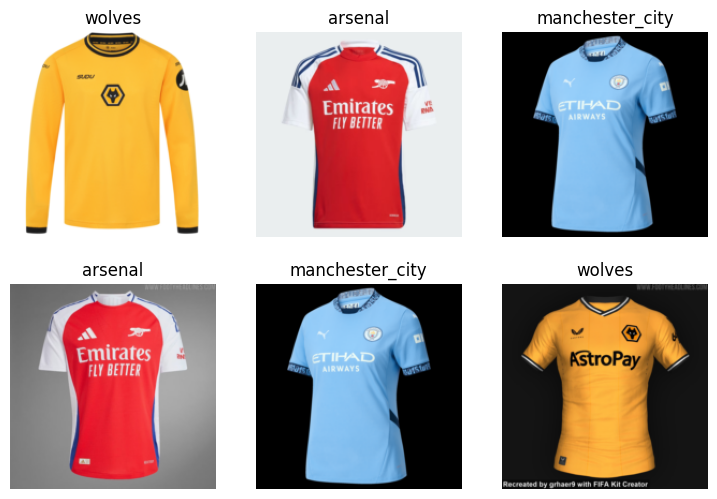

In [24]:
from ddgs import DDGS
from fastai.vision.all import *
import time

clubs = ['Arsenal', 'Manchester City', 'Newcastle United', 'Wolves']
dest = Path('Football Teams')

for club in clubs:
    path = dest / club.lower().replace(" ", "_")
    path.mkdir(exist_ok=True, parents=True)
    results = DDGS().images(f'{club} Home Jerseys 2024', max_items=120)
    urls = [r['image'] for r in results]
    download_images(path, urls=urls)
    time.sleep(2)
    resize_images(dest/club, max_size=300, dest=dest/club)

failed = verify_images(get_image_files(dest))
failed.map(Path.unlink)
len(failed)

for club in clubs:
    folder = dest / club.lower().replace(' ', '_')
    print(club, len(get_image_files(folder)))


# dls = ImageDataLoaders.from_folder(dest, valid_pct=0.2, item_tfms=Resize(224))
# learn = vision_learner(dls, resnet18, metrics=error_rate)
# learn.fine_tune(3)


dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(dest, bs=32)
dls.show_batch(max_n=6)






In [25]:
is_item,_,prob = learn.predict(PILImage.create('Football Teams/arsenal/arsenal.jpg'))
print(f'the image is a picture of {is_item} club jersey')
print(f'the probability of this is {prob[0]:.4f}')

the image is a picture of arsenal club jersey
the probability of this is 0.9999
